# Team Style Qualities

Compute **7 team style qualities** (Twelve Football formulas) for every team involved in v4 transfers.

**Process:**
1. Load raw `team_stats_season.parquet` (full league populations needed for z-scoring)
2. Compute within-(competition, season) z-scores for the 21 metrics used in quality formulas
3. Negate z-scores for `higher_is_better=False` metrics (from `team.py`): **ppda**, **long_ball_pct**
4. Compute **current qualities** = weighted sum of z-scores within same (comp, season)
5. Compute **projected qualities** = same raw stats, z-scored against NEXT season's league population
6. Filter to only teams relevant to v4, save standalone parquet

**Min league size: 5 teams** — (comp, season) groups with fewer are excluded and documented.

**Output:** `thesis_model_dataset/team_qualities.parquet`

---

### Quality formulas (from `twelve_qualities/team_qualities.txt`)

| Quality | Metrics (weight) |
|---------|------------------|
| **Defence** | defensive_intensity (1), ppda (1), final_third_recoveries_pct (1), defensive_action_height_m (1) |
| **Defensive Transition** | recoveries_within_5s_pct (1), time_to_def_action_after_loss_att_half (2), time_to_def_action_after_loss_own_half (1) |
| **Attacking Transition** | possessions_retained_after_5s_pct (0.5), final_third_entry_within_10s_after_recovery_own_half_pct (0.5), first_pass_forward_after_recovery_own_half_pct (1), median_time_to_first_forward_pass_own_half_s (0.5) |
| **Attack** | long_ball_pct (2), forward_passes_from_middle_third_pct (1), buildups_from_goalkicks_pct (1) |
| **Penetration** | box_entries_from_carries_pct (2), box_entries_from_crosses_pct (2), crosses_per_final_third_possession (1) |
| **Chance Creation** | shots_per_final_third_pass (1), shots_from_direct_attacks_pct (2), shots_from_sustained_attacks_pct (2) |
| **Outcome** | xpts (1.5), points (1) |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import os

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.4f}".format)

DATA_ROOT = "../../../thesis_data"
V4_PATH = f"{DATA_ROOT}/processed_data/thesis_model_dataset/within_league_transfers_v4.parquet"
RAW_TS_PATH = f"{DATA_ROOT}/raw_data/Teams_stats/team_stats_season.parquet"
OUTPUT_PATH = f"{DATA_ROOT}/processed_data/thesis_model_dataset/team_qualities.parquet"

## 1. Identify teams needed from v4

In [2]:
v4 = pd.read_parquet(V4_PATH)
print(f"v4 shape: {v4.shape[0]:,} rows x {v4.shape[1]} columns")

# Collect all unique (team, comp, season) combos from both sides
from_keys = v4[["from_team_id", "from_competition", "from_season"]].rename(
    columns={"from_team_id": "team_id", "from_competition": "competition_id", "from_season": "season"}
)
to_keys = v4[["to_team_id", "to_competition", "to_season"]].rename(
    columns={"to_team_id": "team_id", "to_competition": "competition_id", "to_season": "season"}
)
needed_keys = pd.concat([from_keys, to_keys]).drop_duplicates().reset_index(drop=True)

print(f"\nUnique (team, comp, season) needed: {len(needed_keys):,}")
print(f"Unique competitions: {needed_keys['competition_id'].nunique()}")
print(f"Unique seasons: {sorted(needed_keys['season'].unique())}")
print(f"Unique teams: {needed_keys['team_id'].nunique()}")

v4 shape: 18,065 rows x 210 columns

Unique (team, comp, season) needed: 14,500
Unique competitions: 240
Unique seasons: [np.int16(2018), np.int16(2019), np.int16(2020), np.int16(2021), np.int16(2022), np.int16(2023), np.int16(2024), np.int16(2025)]
Unique teams: 4292


## 2. Load raw team stats & filter to relevant competitions

In [3]:
ts_raw = pd.read_parquet(RAW_TS_PATH)
print(f"Raw team stats: {ts_raw.shape[0]:,} rows x {ts_raw.shape[1]} columns")

# Filter to competitions that appear in v4
target_comps = needed_keys["competition_id"].unique()

# Seasons needed: all v4 seasons + season+1 for projection
v4_seasons = needed_keys["season"].unique()
target_seasons = set(v4_seasons) | {s + 1 for s in v4_seasons}

ts = ts_raw[
    (ts_raw["competition_id"].isin(target_comps)) &
    (ts_raw["season"].isin(target_seasons))
].copy()

print(f"\nFiltered to relevant comps & seasons: {len(ts):,} rows")
print(f"Competitions: {ts['competition_id'].nunique()}")
print(f"Seasons: {sorted(ts['season'].unique())}")
print(f"Teams: {ts['team_id'].nunique()}")

Raw team stats: 36,228 rows x 77 columns

Filtered to relevant comps & seasons: 23,632 rows
Competitions: 214
Seasons: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]
Teams: 5195


## 3. Define quality formulas & metric sign handling

From `twelve_qualities/team_qualities.txt` and `twelve_qualities/team.py`.

Quality weights are all positive — sign correction happens at the z-score level via  
`higher_is_better=False` (from `team.py`): the z-score gets **negated** for those metrics.

In [4]:
QUALITIES = {
    "DEFENCE": {
        "defensive_intensity": 1.0,
        "ppda": 1.0,
        "final_third_recoveries_pct": 1.0,
        "defensive_action_height_m": 1.0,
    },
    "DEFENSIVE_TRANSITION": {
        "recoveries_within_5s_pct": 1.0,
        "time_to_defensive_action_after_loss_att_half_s": 2.0,
        "time_to_defensive_action_after_loss_own_half_s": 1.0,
    },
    "ATTACKING_TRANSITION": {
        "possessions_retained_after_5s_pct": 0.5,
        "final_third_entry_within_10s_after_recovery_own_half_pct": 0.5,
        "first_pass_forward_after_recovery_own_half_pct": 1.0,
        "median_time_to_first_forward_pass_own_half_s": 0.5,
    },
    "ATTACK": {
        "long_ball_pct": 2.0,
        "forward_passes_from_middle_third_pct": 1.0,
        "buildups_from_goalkicks_pct": 1.0,
    },
    "PENETRATION": {
        "box_entries_from_carries_pct": 2.0,
        "box_entries_from_crosses_pct": 2.0,
        "crosses_per_final_third_possession": 1.0,
    },
    "CHANCE_CREATION": {
        "shots_per_final_third_pass": 1.0,
        "shots_from_direct_attacks_pct": 2.0,
        "shots_from_sustained_attacks_pct": 2.0,
    },
    "OUTCOME": {
        "xpts": 1.5,
        "points": 1.0,
    },
}

# Metrics where higher_is_better=False in team.py → negate z-score
# ppda: lower PPDA = more pressing
# long_ball_pct: lower long ball % = more build-up play
NEGATE_ZSCORE = {"ppda", "long_ball_pct"}

# Collect all 21 unique metric columns used in formulas
QUALITY_METRICS = sorted({m for weights in QUALITIES.values() for m in weights})
print(f"Quality metrics: {len(QUALITY_METRICS)}")
print(f"Negate z-score: {NEGATE_ZSCORE}")

# Verify all exist in raw team stats
missing = [m for m in QUALITY_METRICS if m not in ts.columns]
if missing:
    print(f"\nWARNING — missing columns in raw team stats: {missing}")
else:
    print(f"All {len(QUALITY_METRICS)} metrics found in raw team stats.")

Quality metrics: 22
Negate z-score: {'long_ball_pct', 'ppda'}
All 22 metrics found in raw team stats.


## 4. Enforce minimum league size (5 teams)

Z-scores are meaningless with < 5 teams. We exclude those (comp, season) groups  
and document which ones were dropped.

In [5]:
MIN_TEAMS = 5

group_sizes = ts.groupby(["competition_id", "season"])["team_id"].nunique()
small_groups = group_sizes[group_sizes < MIN_TEAMS]

print(f"Total (comp, season) groups: {len(group_sizes)}")
print(f"Groups with < {MIN_TEAMS} teams: {len(small_groups)}")

if len(small_groups) > 0:
    print(f"\nSmall groups removed:")
    for (comp, season), n_teams in small_groups.items():
        print(f"  comp={comp}, season={season}: {n_teams} teams")

# Remove small groups
valid_groups = group_sizes[group_sizes >= MIN_TEAMS].index
ts = ts.set_index(["competition_id", "season"])
ts = ts.loc[ts.index.isin(valid_groups)].reset_index()

print(f"\nAfter filter: {len(ts):,} rows, {ts.groupby(['competition_id','season']).ngroups} groups")

# Check if any needed_keys lost their group
valid_set = set(map(tuple, valid_groups.tolist()))
needed_set = set(zip(needed_keys["competition_id"], needed_keys["season"]))
lost = needed_set - valid_set
if lost:
    print(f"\nWARNING: {len(lost)} v4 (comp, season) combos lost due to small league size:")
    for comp, season in sorted(lost):
        n_transfers = len(needed_keys[(needed_keys["competition_id"]==comp) & (needed_keys["season"]==season)])
        print(f"  comp={comp}, season={season} ({n_transfers} team-transfer combos affected)")
else:
    print(f"No v4 teams lost — all in leagues with >= {MIN_TEAMS} teams.")

Total (comp, season) groups: 1435
Groups with < 5 teams: 22

Small groups removed:
  comp=155, season=2020: 4 teams
  comp=165, season=2020: 2 teams
  comp=168, season=2019: 4 teams
  comp=202, season=2018: 4 teams
  comp=232, season=2021: 4 teams
  comp=237, season=2021: 2 teams
  comp=283, season=2018: 3 teams
  comp=286, season=2020: 3 teams
  comp=401, season=2018: 4 teams
  comp=419, season=2020: 3 teams
  comp=534, season=2020: 4 teams
  comp=535, season=2020: 4 teams
  comp=591, season=2025: 2 teams
  comp=716, season=2020: 2 teams
  comp=893, season=2021: 2 teams
  comp=1257, season=2022: 4 teams
  comp=1601, season=2022: 2 teams
  comp=1710, season=2019: 2 teams
  comp=3131, season=2019: 4 teams
  comp=43114, season=2020: 2 teams
  comp=43172, season=2023: 2 teams
  comp=43455, season=2026: 2 teams

After filter: 23,567 rows, 1413 groups

  comp=148, season=2018 (3 team-transfer combos affected)
  comp=165, season=2020 (2 team-transfer combos affected)
  comp=168, season=2019 

## 5. Compute current z-scores

For each metric: `z = (value - league_season_mean) / league_season_std`  
Then negate for `higher_is_better=False` metrics.

In [6]:
# Compute league+season mean and std for each quality metric
group_key = ["competition_id", "season"]
ref_stats = ts.groupby(group_key)[QUALITY_METRICS].agg(["mean", "std"])

# Merge mean/std back to each row (vectorised — no iterrows)
ts_indexed = ts.set_index(group_key)

z_current = pd.DataFrame(index=ts.index)

for col in QUALITY_METRICS:
    means = ref_stats[(col, "mean")]
    stds = ref_stats[(col, "std")]
    
    # Map (comp, season) → mean/std for every row
    idx = pd.MultiIndex.from_arrays([ts["competition_id"], ts["season"]])
    m = means.reindex(idx).values
    s = stds.reindex(idx).values
    
    z = (ts[col].values - m) / np.where(s == 0, np.nan, s)
    
    if col in NEGATE_ZSCORE:
        z = -z
    
    z_current[f"z_{col}"] = z

print(f"Current z-scores: {z_current.shape}")

# Sanity: mean~0, std~1 within each group
sample_cols = ["z_ppda", "z_defensive_intensity", "z_xpts", "z_points"]
print(f"\nZ-score sanity (should be mean≈0, std≈1 within groups):")
for zc in sample_cols:
    grouped = pd.DataFrame({"z": z_current[zc], "comp": ts["competition_id"], "season": ts["season"]})
    g = grouped.groupby(["comp", "season"])["z"].agg(["mean", "std"])
    print(f"  {zc:45s} group_mean=[{g['mean'].min():+.6f}, {g['mean'].max():+.6f}]  group_std=[{g['std'].min():.4f}, {g['std'].max():.4f}]")

Current z-scores: (23567, 22)

Z-score sanity (should be mean≈0, std≈1 within groups):
  z_ppda                                        group_mean=[-0.000000, +0.000000]  group_std=[1.0000, 1.0000]
  z_defensive_intensity                         group_mean=[-0.000000, +0.000000]  group_std=[1.0000, 1.0000]
  z_xpts                                        group_mean=[-0.000000, +0.000000]  group_std=[1.0000, 1.0000]
  z_points                                      group_mean=[-0.000000, +0.000000]  group_std=[1.0000, 1.0000]


## 6. Compute projected z-scores

For a team in season T: take its raw metric values and z-score them against the  
distribution of its competition in season **T+1**.

This answers: *"if this team played exactly the same way next season, how would it rank  
relative to that season's league population?"*

**No projection available** when season T+1 doesn't exist for a competition (last season).  
These rows get NaN projected z-scores and qualities.

In [7]:
z_projected = pd.DataFrame(index=ts.index)

# Build next-season index: (comp, season) → (comp, season+1)
next_idx = pd.MultiIndex.from_arrays([ts["competition_id"], ts["season"] + 1])

for col in QUALITY_METRICS:
    means = ref_stats[(col, "mean")]
    stds = ref_stats[(col, "std")]
    
    # Reindex against next season — NaN where next season doesn't exist
    m = means.reindex(next_idx).values
    s = stds.reindex(next_idx).values
    
    z = (ts[col].values - m) / np.where((s == 0) | np.isnan(s), np.nan, s)
    
    if col in NEGATE_ZSCORE:
        z = -z
    
    z_projected[f"z_proj_{col}"] = z

# How many rows got projections?
has_proj = z_projected.notna().any(axis=1).sum()
no_proj = z_projected.isna().all(axis=1).sum()

print(f"Projected z-scores: {z_projected.shape}")
print(f"Rows WITH projection:    {has_proj:,}")
print(f"Rows WITHOUT projection: {no_proj:,} (last season per competition — expected)")

# Which seasons lack projection?
no_proj_seasons = ts.loc[z_projected.isna().all(axis=1), ["competition_id", "season"]]
print(f"\nSeasons without projection:")
print(no_proj_seasons["season"].value_counts().sort_index().to_string())

Projected z-scores: (23567, 22)
Rows WITH projection:    19,278
Rows WITHOUT projection: 4,289 (last season per competition — expected)

Seasons without projection:
season
2018      35
2019     223
2020     126
2022     170
2023      80
2024     138
2025    3059
2026     458


## 7. Compute team qualities

Each quality = weighted sum of z-scores / total weight.

In [8]:
def compute_qualities(z_df, prefix, z_col_prefix):
    """Compute 7 team qualities from z-score columns.
    
    quality = sum(weight_i * z_i) / sum(weight_i)
    If ALL z-scores for a quality are NaN → quality = NaN.
    """
    result = pd.DataFrame(index=z_df.index)
    
    for quality_name, weights in QUALITIES.items():
        weighted_sum = pd.Series(0.0, index=z_df.index)
        total_weight = 0
        any_valid = pd.Series(False, index=z_df.index)
        
        for metric_col, weight in weights.items():
            z_col = f"{z_col_prefix}{metric_col}"
            if z_col in z_df.columns:
                valid = z_df[z_col].notna()
                any_valid = any_valid | valid
                weighted_sum += weight * z_df[z_col].fillna(0)
                total_weight += weight
        
        if total_weight > 0:
            weighted_sum = weighted_sum / total_weight
        
        weighted_sum[~any_valid] = np.nan
        result[f"{prefix}{quality_name}"] = weighted_sum
    
    return result


# Current qualities
q_current = compute_qualities(z_current, prefix="q_", z_col_prefix="z_")
print("CURRENT QUALITIES")
print(q_current.describe().round(4).to_string())

# Projected qualities
q_projected = compute_qualities(z_projected, prefix="q_proj_", z_col_prefix="z_proj_")
print(f"\nPROJECTED QUALITIES")
print(q_projected.describe().round(4).to_string())

CURRENT QUALITIES
       q_DEFENCE  q_DEFENSIVE_TRANSITION  q_ATTACKING_TRANSITION   q_ATTACK  q_PENETRATION  q_CHANCE_CREATION  q_OUTCOME
count 23567.0000              23567.0000              23567.0000 23567.0000     23567.0000         23567.0000 23567.0000
mean     -0.0000                  0.0000                 -0.0000    -0.0000         0.0000            -0.0000    -0.0000
std       0.8098                  0.5607                  0.4163     0.5856         0.4951             0.4222     0.9091
min      -3.3514                 -2.1635                 -1.9120    -2.2114        -2.3953            -2.5641    -3.3904
25%      -0.5556                 -0.3836                 -0.2769    -0.4033        -0.3209            -0.2689    -0.6531
50%      -0.0008                 -0.0283                  0.0006    -0.0130         0.0094            -0.0052    -0.0626
75%       0.5581                  0.3651                  0.2762     0.3924         0.3285             0.2680     0.6247
max       3.34

## 8. Assemble & filter to v4 teams

In [9]:
# Assemble full output: IDs + raw quality metrics + current z + projected z + current q + projected q
output = pd.concat([
    ts[["team_id", "competition_id", "season"]].reset_index(drop=True),
    ts[QUALITY_METRICS].reset_index(drop=True),
    z_current.reset_index(drop=True),
    z_projected.reset_index(drop=True),
    q_current.reset_index(drop=True),
    q_projected.reset_index(drop=True),
], axis=1)

print(f"Full output (all teams in leagues): {output.shape}")

# Filter to only (team, comp, season) combos needed by v4
needed_tuples = set(zip(needed_keys["team_id"], needed_keys["competition_id"], needed_keys["season"]))
mask = [
    (t, c, s) in needed_tuples
    for t, c, s in zip(output["team_id"], output["competition_id"], output["season"])
]
output_v4 = output[mask].copy().reset_index(drop=True)

print(f"Filtered to v4 teams: {output_v4.shape}")
print(f"\nKeys in v4 but NOT in output (lost): {len(needed_tuples) - len(output_v4):,}")

Full output (all teams in leagues): (23567, 83)
Filtered to v4 teams: (13817, 83)

Keys in v4 but NOT in output (lost): 683


In [10]:
# Column summary
id_cols = ["team_id", "competition_id", "season"]
raw_cols = QUALITY_METRICS
z_cur_cols = [c for c in output_v4.columns if c.startswith("z_") and not c.startswith("z_proj_")]
z_proj_cols = [c for c in output_v4.columns if c.startswith("z_proj_")]
q_cur_cols = [c for c in output_v4.columns if c.startswith("q_") and not c.startswith("q_proj_")]
q_proj_cols = [c for c in output_v4.columns if c.startswith("q_proj_")]

print(f"Column groups:")
print(f"  IDs:                   {len(id_cols)}")
print(f"  Raw quality metrics:   {len(raw_cols)}")
print(f"  Current z-scores:      {len(z_cur_cols)}")
print(f"  Projected z-scores:    {len(z_proj_cols)}")
print(f"  Current qualities:     {len(q_cur_cols)} → {q_cur_cols}")
print(f"  Projected qualities:   {len(q_proj_cols)} → {q_proj_cols}")
print(f"  TOTAL:                 {output_v4.shape[1]}")

Column groups:
  IDs:                   3
  Raw quality metrics:   22
  Current z-scores:      22
  Projected z-scores:    22
  Current qualities:     7 → ['q_DEFENCE', 'q_DEFENSIVE_TRANSITION', 'q_ATTACKING_TRANSITION', 'q_ATTACK', 'q_PENETRATION', 'q_CHANCE_CREATION', 'q_OUTCOME']
  Projected qualities:   7 → ['q_proj_DEFENCE', 'q_proj_DEFENSIVE_TRANSITION', 'q_proj_ATTACKING_TRANSITION', 'q_proj_ATTACK', 'q_proj_PENETRATION', 'q_proj_CHANCE_CREATION', 'q_proj_OUTCOME']
  TOTAL:                 83


## 9. Validation

In [11]:
# CHECK 1: Current z-scores should have mean~0 within each (comp, season) — use FULL output (all teams)
print("CHECK 1: Current z-score means within (comp, season) — should be ≈0")
for zc in ["z_ppda", "z_xpts", "z_defensive_intensity"]:
    g = output.groupby(["competition_id", "season"])[zc].mean()
    print(f"  {zc:40s} range=[{g.min():+.6f}, {g.max():+.6f}]")

# CHECK 2: Projected z-scores should NOT have mean~0 within current season
print(f"\nCHECK 2: Projected z-scores means (should NOT be exactly 0):")
for zpc in ["z_proj_ppda", "z_proj_xpts"]:
    g = output[output[zpc].notna()].groupby(["competition_id", "season"])[zpc].mean()
    print(f"  {zpc:40s} range=[{g.min():+.4f}, {g.max():+.4f}]")

# CHECK 3: Rows without projection = last season per comp
no_proj_rows = output[output["q_proj_DEFENCE"].isna()]
print(f"\nCHECK 3: Rows without projected qualities: {len(no_proj_rows):,}")
print(f"  Last season per comp (expected):")
last_seasons = output.groupby("competition_id")["season"].max()
no_proj_last = no_proj_rows.groupby("competition_id")["season"].unique()
mismatch = 0
for comp, seasons in no_proj_last.items():
    if not all(s == last_seasons[comp] for s in seasons):
        mismatch += 1
        print(f"    MISMATCH comp={comp}: no_proj seasons={seasons}, last={last_seasons[comp]}")
if mismatch == 0:
    print(f"    All {len(no_proj_last)} comps: only last season lacks projection ✓")

CHECK 1: Current z-score means within (comp, season) — should be ≈0
  z_ppda                                   range=[-0.000000, +0.000000]
  z_xpts                                   range=[-0.000000, +0.000000]
  z_defensive_intensity                    range=[-0.000000, +0.000000]

CHECK 2: Projected z-scores means (should NOT be exactly 0):
  z_proj_ppda                              range=[-5.8083, +2.1753]
  z_proj_xpts                              range=[-2.1565, +1.4415]

CHECK 3: Rows without projected qualities: 4,289
  Last season per comp (expected):
    MISMATCH comp=142: no_proj seasons=[2019 2026], last=2026
    MISMATCH comp=165: no_proj seasons=[2022 2025], last=2025
    MISMATCH comp=168: no_proj seasons=[2018 2025], last=2025
    MISMATCH comp=211: no_proj seasons=[2020 2023], last=2023
    MISMATCH comp=232: no_proj seasons=[2020 2026], last=2026
    MISMATCH comp=237: no_proj seasons=[2020 2026], last=2026
    MISMATCH comp=244: no_proj seasons=[2020 2026], last=2026

In [12]:
# CHECK 4: Spot-check a well-known team across seasons
# Find a team that appears in many seasons
team_season_counts = output_v4.groupby("team_id")["season"].nunique().sort_values(ascending=False)
spot_team = team_season_counts.index[0]
team_data = output_v4[output_v4["team_id"] == spot_team].sort_values("season")

print(f"SPOT CHECK: team_id={spot_team} (comp={team_data['competition_id'].iloc[0]}, {len(team_data)} seasons)")
print(f"\nCurrent qualities:")
print(team_data[["season"] + q_cur_cols].to_string(index=False))
print(f"\nProjected qualities:")
print(team_data[["season"] + q_proj_cols].to_string(index=False))

SPOT CHECK: team_id=3192 (comp=527, 8 seasons)

Current qualities:
 season  q_DEFENCE  q_DEFENSIVE_TRANSITION  q_ATTACKING_TRANSITION  q_ATTACK  q_PENETRATION  q_CHANCE_CREATION  q_OUTCOME
   2018    -0.7588                  0.9571                 -0.4165   -0.5740         0.9239            -0.4752    -0.4236
   2019     0.0226                 -0.4450                 -0.4957   -0.0527         0.1885            -0.2444    -0.1466
   2020    -0.6364                  0.0894                  0.4274   -1.5376        -0.1453             0.5532     0.5269
   2021    -1.3901                  2.3799                 -0.0124   -0.2461         0.4886            -0.3532    -1.0939
   2022    -1.2998                  0.7139                 -0.0279   -0.0497         0.5466            -0.2037    -1.1597
   2023    -0.9180                  0.6717                 -0.1717    0.1516         0.1750             0.1324    -2.0091
   2024    -0.1803                  0.2700                  0.0205    0.1639   

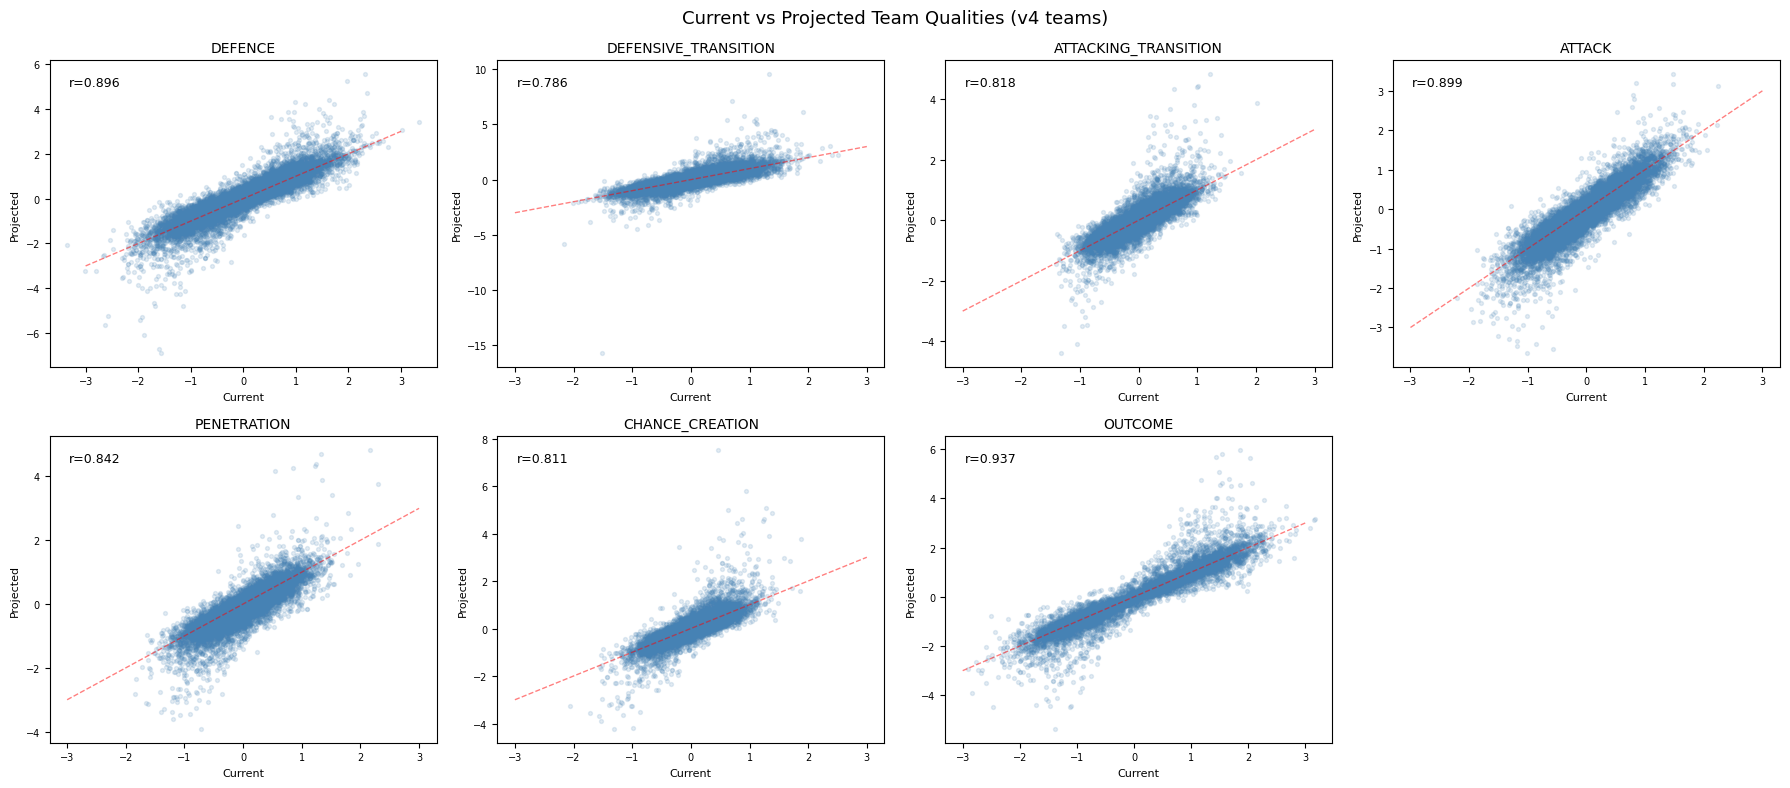

In [13]:
# CHECK 5: Current vs projected scatter — should be correlated but not identical
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flat

for i, q_name in enumerate(QUALITIES.keys()):
    ax = axes[i]
    valid = output_v4[output_v4[f"q_proj_{q_name}"].notna()]
    ax.scatter(valid[f"q_{q_name}"], valid[f"q_proj_{q_name}"],
              alpha=0.15, s=8, color="steelblue")
    ax.plot([-3, 3], [-3, 3], "r--", lw=1, alpha=0.5)
    ax.set_xlabel("Current", fontsize=8)
    ax.set_ylabel("Projected", fontsize=8)
    ax.set_title(q_name, fontsize=10)
    ax.tick_params(labelsize=7)
    r = valid[[f"q_{q_name}", f"q_proj_{q_name}"]].corr().iloc[0, 1]
    ax.text(0.05, 0.95, f"r={r:.3f}", transform=ax.transAxes, fontsize=9, va="top")

axes[7].set_visible(False)
plt.suptitle("Current vs Projected Team Qualities (v4 teams)", fontsize=13)
plt.tight_layout()
plt.show()

## 10. Save

In [14]:
output_v4.to_parquet(OUTPUT_PATH, index=False)
size_mb = os.path.getsize(OUTPUT_PATH) / 1e6

print(f"Saved: {OUTPUT_PATH}")
print(f"Size:  {size_mb:.1f} MB")
print(f"Shape: {output_v4.shape[0]:,} rows x {output_v4.shape[1]} columns")
print(f"\n=== SUMMARY ===")
print(f"Teams:       {output_v4['team_id'].nunique():,}")
print(f"Competitions: {output_v4['competition_id'].nunique()}")
print(f"Seasons:     {sorted(output_v4['season'].unique())}")
print(f"Qualities:   7 current + 7 projected = 14")
print(f"\nThis parquet is ready to be joined to v4 transfers by (team_id, competition_id, season).")

Saved: ../../../thesis_data/processed_data/thesis_model_dataset/team_qualities.parquet
Size:  9.6 MB
Shape: 13,817 rows x 83 columns

=== SUMMARY ===
Teams:       4,057
Competitions: 214
Seasons:     [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Qualities:   7 current + 7 projected = 14

This parquet is ready to be joined to v4 transfers by (team_id, competition_id, season).
